## What is remote sensing?

Remote sensing is the science of obtaining information about the Earth’s surface without making physical contact with it. Instead of ground-based measurements, remote sensing systems use sensors on satellites, aircraft, or drones to record reflected or emitted energy, most often in the visible, infrared, and microwave regions of the electromagnetic spectrum.

These sensors measure how different surfaces (such as vegetation, water, soil, and built-up areas) interact with incoming radiation, producing multi- or hyperspectral images in which each pixel contains a spectral signature. By analysing these signatures over space and time, remote sensing allows us to map land cover, monitor environmental change, and derive biophysical variables at regional to global scales.

ADD IMAGE HERE

## Platforms and sensors in remote sensing

Remote sensing platforms are the carriers that bring sensors into position to observe the Earth, typically grouped into ground‑based, drone (UAV), aircraft, and satellite systems. Each platform type differs in altitude, spatial extent, revisit time, and flexibility, which strongly shapes the kind of information it can provide. Choosing the right platform is therefore a trade‑off between spatial detail, temporal coverage, cost, and operational constraints.

Drones fly at very low altitude and can collect imagery with centimetre‑scale resolution, making them ideal for field‑scale studies, calibration/validation, and experiments where you need full control over timing and sensor configuration. Their limitations are small coverage per flight, regulatory restrictions, and susceptibility to local weather conditions. Airborne campaigns (manned aircraft) cover larger areas than drones while still offering very high spatial and spectral resolution, including advanced hyperspectral and thermal sensors, but are expensive and usually limited to short campaigns.

Satellites provide systematic, long‑term observations over large regions to the entire globe, with stable acquisitions and well‑characterised radiometric calibration. They typically have coarser spatial resolution than drones or aircraft, but offer regular revisit cycles and long archives that are crucial for time‑series analysis and large‑area mapping. In practice, many applications combine platforms: satellite data for broad context and temporal monitoring, airborne/drone data for fine‑scale mapping and algorithm development, and ground measurements for validation and biophysical interpretation.

ADD MAHLEIN IMAGE HERE

## Why use the data in Python (e.g. automation, multi-purpose algorithms, full GIS capabilities, ...)

Python is widely used for remote sensing data analysis because it combines a rich scientific ecosystem with strong support for geospatial data, making it possible to build reproducible, scalable workflows instead of one‑off manual processing steps. With libraries such as NumPy, xarray, and pandas you can handle large multidimensional datasets efficiently, while tools like rasterio, rioxarray, GeoPandas, and PyProj provide full GIS capabilities for projections, vector–raster operations, and spatial indexing. This allows you to move seamlessly from raw satellite scenes to analysis‑ready data, statistics, and maps in a single environment.

Another major advantage is automation. Once you have implemented a workflow—ingest, atmospheric correction, masking, feature extraction, classification—you can run the same code over many scenes, tiles, or time steps with minimal changes. The same scripts can process different sensors or regions by simply changing configuration parameters, which encourages multi‑purpose algorithms and reproducible research. Python also integrates well with machine learning and deep learning frameworks (scikit‑learn, PyTorch, TensorFlow), making it straightforward to test and deploy land‑cover classifiers, segmentation models, or regression models directly on remote sensing data.

Finally, Python is open source and platform independent, with strong community support in both the geospatial and scientific domains. This means you can combine remote sensing tools with web APIs, databases, cloud storage, and interactive visualization (e.g. Jupyter, Holoviz, Folium), and you can share notebooks or scripts that others can run and adapt. Altogether, this makes Python an attractive choice for end‑to‑end remote sensing workflows—from exploratory analysis and method development to automated processing chains and operational services.

## How to get satellite data

Satellite data can be obtained through several complementary routes, depending on whether you want manual downloads for a few scenes or automated access to large, multi-temporal datasets.

A first common route is to use web portals provided by space agencies (SHOW ONE) and data centers. Examples include USGS EarthExplorer for Landsat and many other sensors, ESA’s Copernicus Open Access Hub or related Sentinel portals for Sentinel‑1/2/3, and NASA Earthdata for a broad range of missions. These interfaces let you define an area of interest, time range, and cloud-cover threshold, inspect quicklooks, and then download selected scenes as GeoTIFFs or other formats. This is practical for small projects, teaching, and when you need full control over individual scenes, but becomes cumbersome for large time series or repeated processing.

A second route is to use higher-level platforms and viewers that integrate multiple data sources and provide on-the-fly visualization and simple processing. Examples are browser-based tools such as EO Browser, LandViewer, or various agency-hosted viewers, which allow you to explore many sensors without installing software, sometimes with basic band math or cloud masking in the browser. These are excellent for exploration and quick checks, but they do not replace a full analysis pipeline when you need custom algorithms or integration with other data.

A third route, and the one we will use in this tutorial, is programmatic access via cloud-native services and data cubes, such as cubo. Data cubes reorganize large archives (e.g. Sentinel‑2) into analysis-ready, spatio‑temporal arrays that you can query directly from Python by specifying an area, time range, and product. With tools like cubo, you can automatically fetch and stack many acquisitions into consistent data structures that are ready for machine learning and time‑series analysis, without manually downloading or mosaicking individual scenes. This approach scales much better, encourages reproducible workflows, and integrates smoothly with Python-based GIS and ML libraries, which is why it has become central in modern remote-sensing analysis.

- cubo is a lightweight Python library that talks directly to a STAC backend (e.g. Planetary Computer) and returns xarray data cubes with satellite bands as regular arrays. It’s great when you mainly need to: (1) define an AOI, time range, collection (e.g. Sentinel‑2), and cloud filter; (2) pull the data into your local Python session; and (3) do all further processing yourself with xarray, NumPy, and ML libraries. It keeps the mental model simple—one create(...) call per cube—and is ideal for notebooks, prototyping, and moderate‑size analyses where you’re happy to run the computation on your machine.

- openEO adds a standardized API and server‑side processing on big EO backends. You use the Python client to build a process graph—load collections (Sentinel‑2, Landsat, etc.), mask clouds, aggregate in time, compute indices—and that graph is executed on the backend’s cluster instead of your laptop. This is attractive when you need to scale to continental/global time series, run the same workflow across different providers, or share reproducible processing graphs with others. It’s more powerful and flexible for large workloads, but also a bit heavier to learn and depends on backend performance and configuration.

In [ ]:
- CUBO (https://planetarycomputer.microsoft.com/)
- What is stack
- what is a landcover classification (2-classes vegetation versus all else)
- classic landcover classification using sentinel 2 data
- disadvantages of S2 data (individual scenes of raw spectral reflectance data, large number of labels)
- foundation models are promising to reduce labelling effort by producing abstract location representations of each pixel where normally a spectral band would be used
- geo embeddings 
- what are embeddings

In [14]:
import cubo # better open EO?
import xarray as xr

# Göttingen, Germany (lon/lat -> 9.93, 51.54)
lon, lat = 9.93, 51.54

da = cubo.create(
    lat=lat,
    lon=lon,
    collection="sentinel-2-l2a",
    bands=["B02", "B03", "B04", "B08"],  # blue, green, red, nir
    start_date="2025-08-01",
    end_date="2025-08-07",
    edge_size=64,
    resolution=10,
    query={"eo:cloud_cover": {"lt": 20}},
)

# Optional: inspect timestamps and cloud cover metadata
print(da.time.values)
print(da["eo:cloud_cover"].values)

# Optional: save lazily-loaded cube to NetCDF
# da.to_netcdf("goettingen_s2_2025_lt25cloud.nc")

APIError: The request exceeded the maximum allowed time, please try again. If the issue persists, please contact planetarycomputer@microsoft.com.



In [ ]:
import cubo
import matplotlib.pyplot as plt

# Göttingen city center (lon, lat)
lon, lat = 9.93, 51.54

# Build a small Landsat LST cube for 2025
da = cubo.create(
    lat=lat,
    lon=lon,
    collection="landsat-8-c2-l2",      # adjust to your STAC collection name
    bands=["ST_B10"],                  # LST band in Kelvin for L8/9 C2 L2
    start_date="2025-08-01",
    end_date="2025-09-01",
    edge_size=128,                     # pixels from center (area ~ (2*edge_size * resolution)^2)
    resolution=30,                     # Landsat thermal native resolution (30 m LST product) [web:50]
    query={"eo:cloud_cover": {"lt": 25}},
)

print("Times:", da.time.values)

# Pick least cloudy acquisition if cloud metadata is present
if "eo:cloud_cover" in da:
    best_idx = da["eo:cloud_cover"].argmin().item()
    lst_scene = da.isel(time=best_idx).squeeze()
else:
    lst_scene = da.isel(time=0).squeeze()

# lst_scene now has shape (y, x) with surface temperature in Kelvin
print("LST range (K):", float(lst_scene.min()), float(lst_scene.max()))

# Simple visualization
plt.figure(figsize=(6, 5))
im = plt.imshow(lst_scene, cmap="inferno")
plt.title("Landsat LST (ST_B10) – Göttingen")
plt.axis("off")
plt.colorbar(im, label="Temperature (K)")
plt.tight_layout()
plt.show()

In [1]:
#pip install geotessera matplotlib jupyter
#https://geotessera.readthedocs.io/en/latest/tutorials.html#tutorial-1-basic-data-analysis
import numpy as np
import matplotlib.pyplot as plt
from geotessera import GeoTessera
import json

In [2]:
# Initialize with default settings
gt = GeoTessera()

# Check available years
years = gt.registry.get_available_years()
print(f"Available years: {years}")

Available years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [7]:
# Generate a coverage map
# CLI command (preferred):
# geotessera coverage --year 2024 --output global_coverage.png

# For specific regions with boundary visualization:
# geotessera coverage --country "United Kingdom" --year 2024  # Shows precise UK boundaries
# geotessera coverage --region-file study_area.geojson --year 2024  # Shows custom region outline

# Or using Python API:
from geotessera.visualization import visualize_global_coverage

visualize_global_coverage(
    tessera_client=gt,
    output_path="global_coverage.png",
    year=2024,
    width_pixels=2000,
    tile_color="blue",
    tile_alpha=0.4
)

#print("Coverage map saved to global_coverage.png")
#print("Next step: Download data for your region")
#print("For better regional focus, use: geotessera coverage --country

'global_coverage.png'

In [8]:
# Download embedding for Goettingen (note: lon, lat order)
lon, lat = 9.93, 51.54  # approx. Göttingen city center
year = 2025

embedding, crs, transform = gt.fetch_embedding(lon=lon, lat=lat, year=year)

print(f"Embedding shape: {embedding.shape}")
print(f"Data type: {embedding.dtype}")
print(f"CRS: {crs}")
print(f"Transform: {transform}")
print(f"Value range: [{embedding.min():.3f}, {embedding.max():.3f}]")
print(f"Memory usage: {embedding.nbytes / 1024**2:.1f} MB")

Embedding shape: (1121, 708, 128)
Data type: float32
CRS: EPSG:32632
Transform: | 10.00, 0.00, 562334.07|
| 0.00,-10.00, 5717024.29|
| 0.00, 0.00, 1.00|
Value range: [-13.361, 17.155]
Memory usage: 387.5 MB


In [9]:
# Per-channel statistics
mean_per_channel = np.mean(embedding, axis=(0, 1))
std_per_channel = np.std(embedding, axis=(0, 1))

print("First 10 channels:")
for i in range(10):
    print(f"  Channel {i:2d}: mean={mean_per_channel[i]:6.3f}, "
          f"std={std_per_channel[i]:6.3f}")

# Spatial statistics
center_pixel = embedding[embedding.shape[0]//2, embedding.shape[1]//2, :]
corner_pixel = embedding[0, 0, :]

print(f"\nCenter pixel (first 5 channels): {center_pixel[:5]}")
print(f"Corner pixel (first 5 channels): {corner_pixel[:5]}")

First 10 channels:
  Channel  0: mean= 3.558, std= 2.300
  Channel  1: mean= 0.071, std= 1.585
  Channel  2: mean=-0.735, std= 1.617
  Channel  3: mean= 3.416, std= 1.623
  Channel  4: mean=-0.609, std= 1.325
  Channel  5: mean=-0.792, std= 2.553
  Channel  6: mean=-2.969, std= 1.839
  Channel  7: mean=-0.896, std= 1.806
  Channel  8: mean= 0.208, std= 1.199
  Channel  9: mean= 1.722, std= 1.745

Center pixel (first 5 channels): [ 4.0759583   1.4109086   0.47030285  2.8218172  -0.88834983]
Corner pixel (first 5 channels): [ 1.6358323 -1.2268742  0.         2.3515089 -1.9425509]


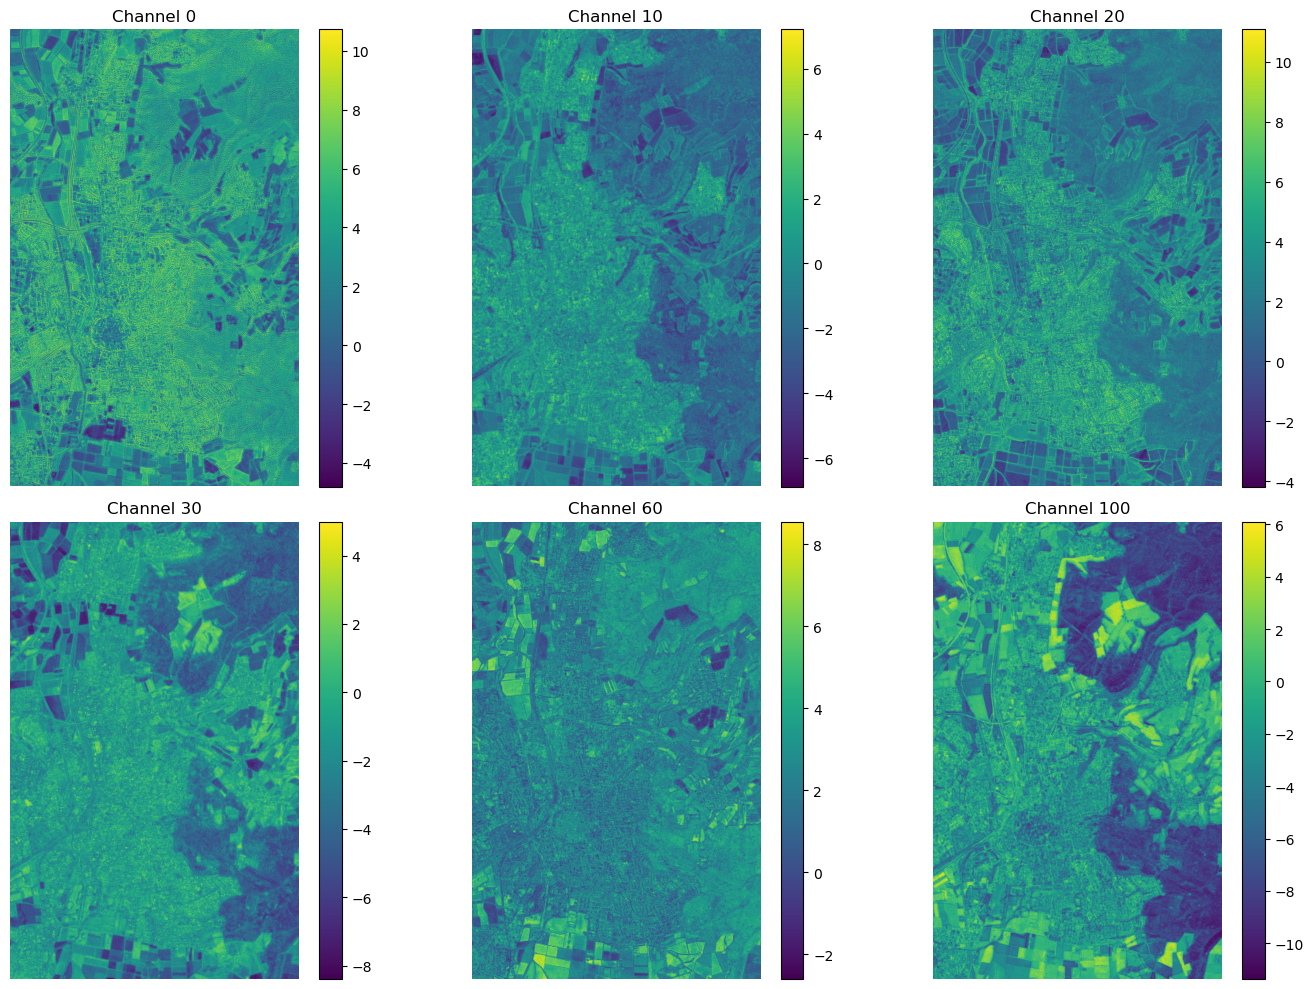

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Visualize channels 0, 10, 20, 30, 60, 100
channels_to_plot = [0, 10, 20, 30, 60, 100]

for i, channel in enumerate(channels_to_plot):
    ax = axes[i]
    im = ax.imshow(embedding[:, :, channel], cmap='viridis')
    ax.set_title(f'Channel {channel}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('cambridge_channels.png', dpi=150, bbox_inches='tight')
plt.show()